# Sample script for plotting a time-height cross section

## Required packages
- numpy
- xarray
- matplotlib

In [1]:
from datetime import datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from bsod2 import Sonde

## Read observational data and perform quality control.

In [2]:
# station name and sonde number mapping based on the field book.
# Note that the station name (e.g., "St.4a") is only for labeling the plot and is not used for QC.
# The sonde number is used to identify the corresponding data file.

field_book = {
        "St.4a": ["1101771",datetime(2024,6,18,6,31)],
        "St.4b": ["1101323",datetime(2024,6,18,9,1)],
        "St.4c": ["1101386",datetime(2024,6,18,10,1)],
        "St.4d": ["1101322",datetime(2024,6,18,11,0)],
        "St.4e": ["1101327",datetime(2024,6,18,12,18)],
        "St.4f": ["1101772",datetime(2024,6,18,13,0)],
        "St.4g": ["1101388",datetime(2024,6,18,14,0)],
        "St.4h": ["1101326",datetime(2024,6,18,15,0)],
    }

raw_data_dir = Path("Seisuimaru2407/raw_data")  # raw data directory

data = {}
for st_name, (sonde_no, valid_time) in field_book.items():
    fpath = next(raw_data_dir.glob(f"F*S{sonde_no}.CSV"))
    data[st_name] = [Sonde(fpath,interp="z"),valid_time]

## Create a Dataset with observation station names and altitude as coordinates.

In [3]:
# rename variables for easier access and plotting
var_dict = {
    "Time":"time",
    "Tmp":"tmp",
    "Prs":"p",
    "WD":"wd",
    "WS":"ws",
    "Hum":"rh",
    }

# make 2D arrays for each variable (station x height)
arr_dict = {}
for old_name, new_name in var_dict.items():
    arr = []
    for st_name in data.keys():
        arr.append(data[st_name][0].df[old_name].values)
    arr_dict[new_name] = np.array(arr)

ds = xr.Dataset(
    data_vars={
        "p": (("station", "z"), arr_dict["p"]),
        "tmp": (("station", "z"), arr_dict["tmp"]),
        "wd": (("station", "z"), arr_dict["wd"]),
        "ws": (("station", "z"), arr_dict["ws"]),
        "rh": (("station", "z"), arr_dict["rh"]),
        "valid_time": ("station", [v[1] for v in data.values()]),
        "time": (("station", "z"), arr_dict["time"]),
    },
    coords={
        "station": list(data.keys()),
        "z": data["St.4a"][0].df["Height"].values,
    },
)
    
ds

<xarray.Dataset> Size: 785kB
Dimensions:     (station: 8, z: 2001)
Coordinates:
  * station     (station) <U5 160B 'St.4a' 'St.4b' 'St.4c' ... 'St.4g' 'St.4h'
  * z           (z) float64 16kB 0.0 10.0 20.0 ... 1.998e+04 1.999e+04 2e+04
Data variables:
    p           (station, z) float64 128kB nan 1.007e+03 1.005e+03 ... nan nan
    tmp         (station, z) float64 128kB nan 18.76 18.93 19.0 ... nan nan nan
    wd          (station, z) float64 128kB nan 270.4 252.9 250.7 ... nan nan nan
    ws          (station, z) float64 128kB nan 2.426 2.09 2.16 ... nan nan nan
    rh          (station, z) float64 128kB nan 89.21 89.78 90.21 ... nan nan nan
    valid_time  (station) datetime64[ns] 64B 2024-06-18T06:31:00 ... 2024-06-...
    time        (station, z) datetime64[ns] 128kB NaT ... NaT

## Plot Time–height cross section of humidity

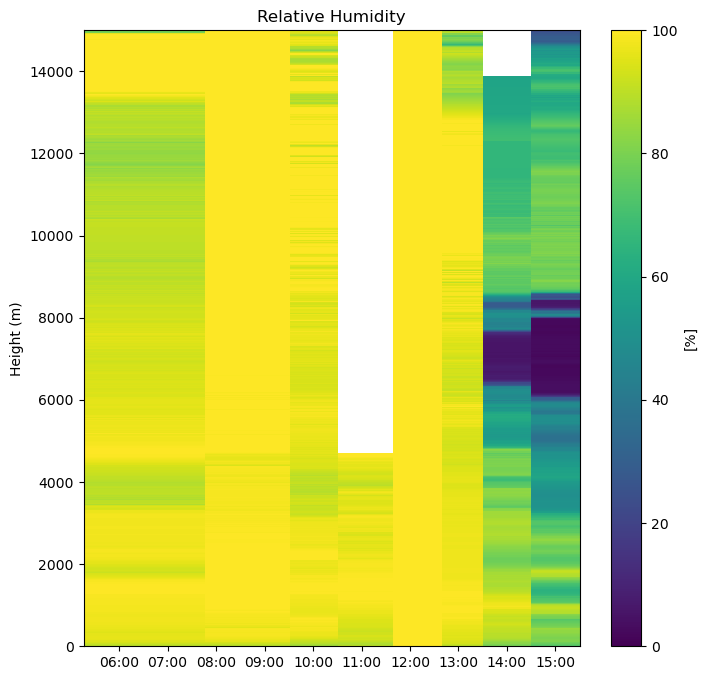

In [4]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_title("Relative Humidity")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_ylim(0,15000)
ax.set_ylabel("Height (m)")


pm = ax.pcolormesh(ds["valid_time"], ds["z"], ds["rh"].T, shading="auto")
fig.colorbar(pm, ax=ax, label="[%]")

plt.show()